# COSC2671 — Assignment 2: Virality Factor Analysis & ML Classification
## What Makes a YouTube Gaming Video Go Viral?

This notebook brings together all engineered features to answer the core research question.

**Part A — Correlation Analysis**
- Identify which content, community, and NLP features correlate most strongly with virality
- Spearman correlation with statistical validation

**Part B — Feature Engineering**
- Combine metadata, network, and NLP features into a single feature matrix

**Part C — ML Classification (Bonus / HD Component)**
- Predict virality tier using Random Forest, Logistic Regression, Gradient Boosting
- Feature importance ranking
- 5-fold cross-validated evaluation

**Inputs:** `data/videos.csv`, `data/video_nlp_features.csv`, `data/node_features.csv`
**Outputs:** `data/feature_matrix.csv`, `data/correlation_results.csv`, `data/virality_profile.csv`, figures

## Cell 1 — Imports & Load Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from scipy import stats
from scipy.stats import spearmanr
from collections import Counter
from matplotlib.patches import Patch

from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

plt.rcParams['figure.figsize'] = (13, 6)
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
sns.set_palette('Set2')

TIER_ORDER  = ['viral', 'mid', 'non_viral']
TIER_COLORS = {'viral': '#2ecc71', 'mid': '#f39c12', 'non_viral': '#e74c3c'}

videos_df     = pd.read_csv('data/videos.csv')
video_nlp_df  = pd.read_csv('data/video_nlp_features.csv')
node_features = pd.read_csv('data/node_features.csv')
comments_df   = pd.read_csv('data/comments_sentiment.csv')

print(f"Videos:        {len(videos_df):,}")
print(f"Video NLP:     {len(video_nlp_df):,}")
print(f"Network nodes: {len(node_features):,}")
print(f"Comments:      {len(comments_df):,}")

Videos:        558
Video NLP:     558
Network nodes: 377
Comments:      29,193


## Cell 2 — Feature Engineering

In [4]:
# Start from video NLP feature table
base_cols = [
    'video_id', 'niche', 'virality_tier', 'normalised_views',
    'view_count', 'like_count', 'comment_count_x', 'duration_seconds',
    'subscriber_count', 'avg_compound', 'std_compound',
    'pct_positive', 'pct_negative', 'pct_neutral',
    'dominant_topic', 'avg_topic_prob',
]

base_cols = [c for c in base_cols if c in video_nlp_df.columns]

features_df = video_nlp_df[base_cols].copy()

# Rename for consistency
features_df.rename(columns={'comment_count_x': 'comment_count'}, inplace=True)

# Engagement ratios
features_df['like_view_ratio'] = (
    features_df['like_count'] / (features_df['view_count'] + 1)
)

features_df['comment_view_ratio'] = (
    features_df['comment_count'] / (features_df['view_count'] + 1)
)

features_df['duration_minutes'] = (
    features_df['duration_seconds'] / 60
)

# Merge title/tag/date from videos_df
features_df = features_df.merge(
    videos_df[['video_id', 'title', 'tags', 'published_at']],
    on='video_id', how='left'
)

# Title features
features_df['title_length']        = features_df['title'].str.len().fillna(0)
features_df['title_word_count']    = features_df['title'].str.split().str.len().fillna(0)
features_df['tag_count']           = features_df['tags'].str.split('|').str.len().fillna(0)
features_df['title_has_excl']      = features_df['title'].str.contains('!', na=False).astype(int)
features_df['title_has_question']  = features_df['title'].str.contains('\\?', na=False).astype(int)
features_df['title_has_number']    = features_df['title'].str.contains('\\d', na=False, regex=True).astype(int)
features_df['title_caps_words']    = features_df['title'].str.findall(r'\b[A-Z]{2,}\b').str.len().fillna(0)

# Upload timing features
features_df['published_at'] = pd.to_datetime(features_df['published_at'], errors='coerce', utc=True)
features_df['upload_hour']  = features_df['published_at'].dt.hour
features_df['upload_dow']   = features_df['published_at'].dt.dayofweek
features_df['upload_month'] = features_df['published_at'].dt.month

# Network features: aggregate commenter centrality per video
comment_centrality = comments_df.merge(
    node_features[['user_id', 'degree_centrality', 'betweenness_centrality',
                   'eigenvector_centrality', 'pagerank', 'community']],
    left_on='author_channel_id', right_on='user_id', how='left'
)
video_net = (
    comment_centrality.groupby('video_id')
    .agg(
        avg_commenter_degree=('degree_centrality', 'mean'),
        max_commenter_degree=('degree_centrality', 'max'),
        avg_pagerank=('pagerank', 'mean'),
        max_pagerank=('pagerank', 'max'),
        n_communities=('community', 'nunique'),
        avg_betweenness=('betweenness_centrality', 'mean'),
    ).reset_index()
)
features_df = features_df.merge(video_net, on='video_id', how='left')

# Numeric virality target for correlation
tier_numeric = {'viral': 2, 'mid': 1, 'non_viral': 0}
features_df['virality_numeric'] = features_df['virality_tier'].map(tier_numeric)

features_df.to_csv('data/feature_matrix.csv', index=False)
print(f"Feature matrix: {features_df.shape}")

Feature matrix: (558, 39)


## Cell 3 — Define Feature Set & Spearman Correlation

In [5]:
NUMERIC_FEATURES = [
    'duration_minutes', 'subscriber_count',
    'title_length', 'title_word_count', 'tag_count',
    'title_has_excl', 'title_has_question', 'title_has_number', 'title_caps_words',
    'upload_hour', 'upload_dow', 'upload_month',
    'like_view_ratio', 'comment_view_ratio',
    'avg_compound', 'std_compound', 'pct_positive', 'pct_negative', 'pct_neutral',
    'avg_topic_prob',
    'avg_commenter_degree', 'max_commenter_degree',
    'avg_pagerank', 'max_pagerank',
    'n_communities', 'avg_betweenness',
]
NUMERIC_FEATURES = [f for f in NUMERIC_FEATURES if f in features_df.columns]

# Spearman correlation — robust to skew and ordinal targets
valid = features_df.dropna(subset=['virality_numeric'])
rows = []
for feat in NUMERIC_FEATURES:
    col = valid[feat].dropna()
    if len(col) < 10:
        continue
    rho, p = spearmanr(col, valid.loc[col.index, 'virality_numeric'])
    rows.append({'feature': feat, 'spearman_rho': round(rho, 4),
                 'p_value': round(p, 6), 'significant': p < 0.05, 'abs_rho': abs(rho)})

corr_df = pd.DataFrame(rows).sort_values('abs_rho', ascending=False)
corr_df.to_csv('data/correlation_results.csv', index=False)

print("Spearman correlations with virality (sorted by |rho|):")
print(corr_df[['feature', 'spearman_rho', 'p_value', 'significant']].to_string(index=False))

Spearman correlations with virality (sorted by |rho|):
             feature  spearman_rho  p_value  significant
    subscriber_count       -0.5085 0.000000         True
        avg_pagerank       -0.2514 0.015651         True
     like_view_ratio       -0.2404 0.000000         True
  comment_view_ratio       -0.2087 0.000001         True
        avg_compound        0.1878 0.000009         True
        pct_positive        0.1369 0.001294         True
        pct_negative       -0.1241 0.003567         True
        max_pagerank       -0.1151 0.274677        False
    title_word_count        0.1133 0.007401         True
        title_length        0.0958 0.023678         True
      title_has_excl       -0.0828 0.050507        False
       n_communities        0.0795 0.062434        False
    duration_minutes       -0.0753 0.075427        False
         pct_neutral       -0.0678 0.112143        False
  title_has_question       -0.0534 0.207493        False
         upload_hour        0.050

## Cell 4 — Visualisation 1: Correlation Bar Chart & Heatmap

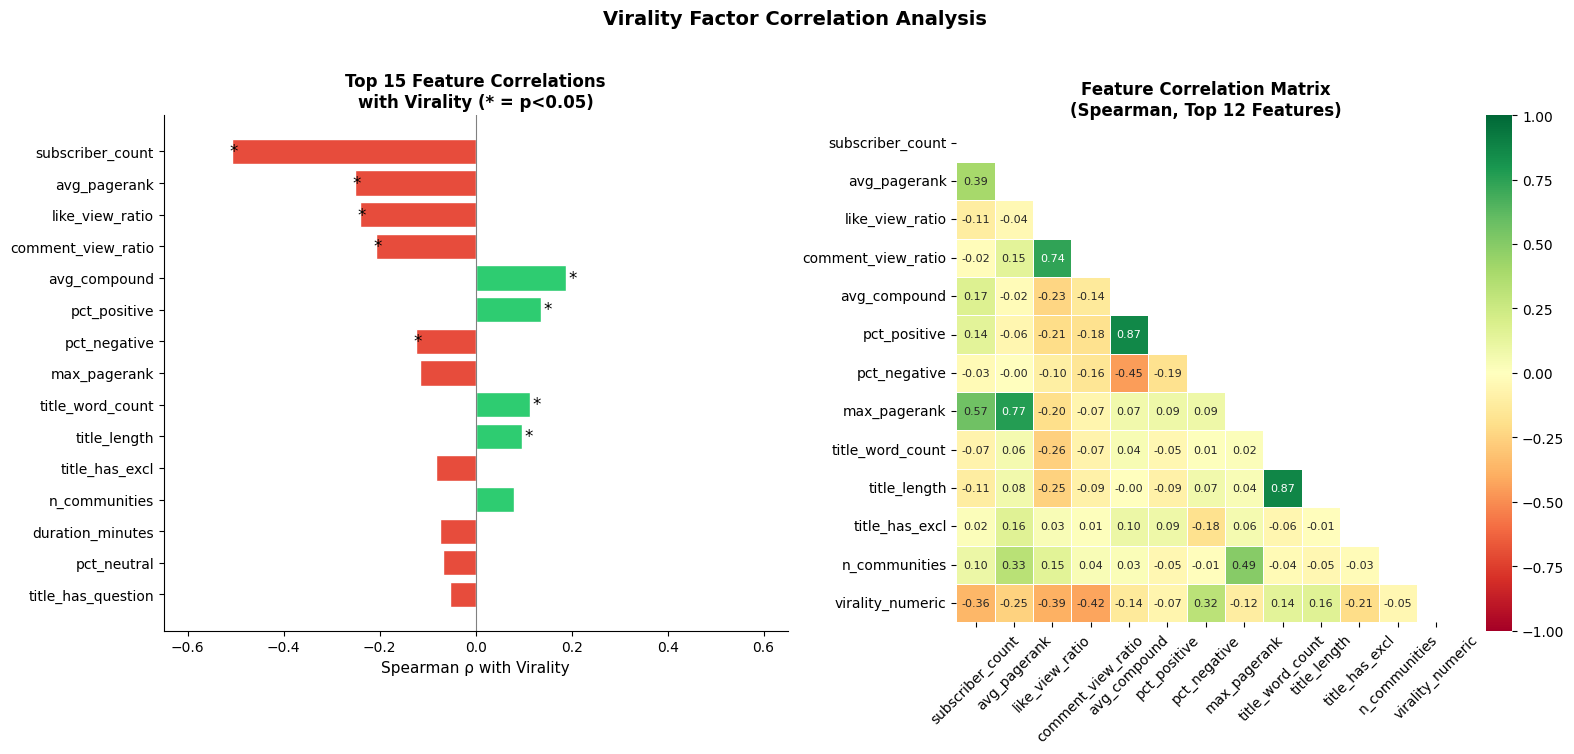

Saved: data/fig_correlation_analysis.png


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Bar chart
ax = axes[0]
top15 = corr_df.head(15)
colors = ['#2ecc71' if r > 0 else '#e74c3c' for r in top15['spearman_rho']]
ax.barh(top15['feature'][::-1], top15['spearman_rho'][::-1],
        color=colors[::-1], edgecolor='white')
for i, (_, row) in enumerate(top15[::-1].iterrows()):
    if row['significant']:
        ax.text(row['spearman_rho'] + 0.005 * np.sign(row['spearman_rho']),
                i, '*', va='center', fontsize=12)
ax.axvline(0, color='grey', linewidth=0.8)
ax.set_xlabel('Spearman ρ with Virality', fontsize=11)
ax.set_title('Top 15 Feature Correlations\nwith Virality (* = p<0.05)', fontsize=12, fontweight='bold')
ax.set_xlim(-0.65, 0.65)

# Heatmap of top 12 features
ax2 = axes[1]
top_feats = corr_df.head(12)['feature'].tolist()
corr_mat  = features_df[top_feats + ['virality_numeric']].dropna().corr(method='spearman')
mask = np.triu(np.ones_like(corr_mat, dtype=bool))
sns.heatmap(corr_mat, mask=mask, ax=ax2, cmap='RdYlGn', center=0,
            vmin=-1, vmax=1, annot=True, fmt='.2f',
            annot_kws={'size': 8}, linewidths=0.5, square=True)
ax2.set_title('Feature Correlation Matrix\n(Spearman, Top 12 Features)', fontsize=12, fontweight='bold')
ax2.tick_params(axis='x', rotation=45)

plt.suptitle('Virality Factor Correlation Analysis', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('data/fig_correlation_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: data/fig_correlation_analysis.png")

## Cell 5 — Visualisation 2: Top Feature Distributions by Tier

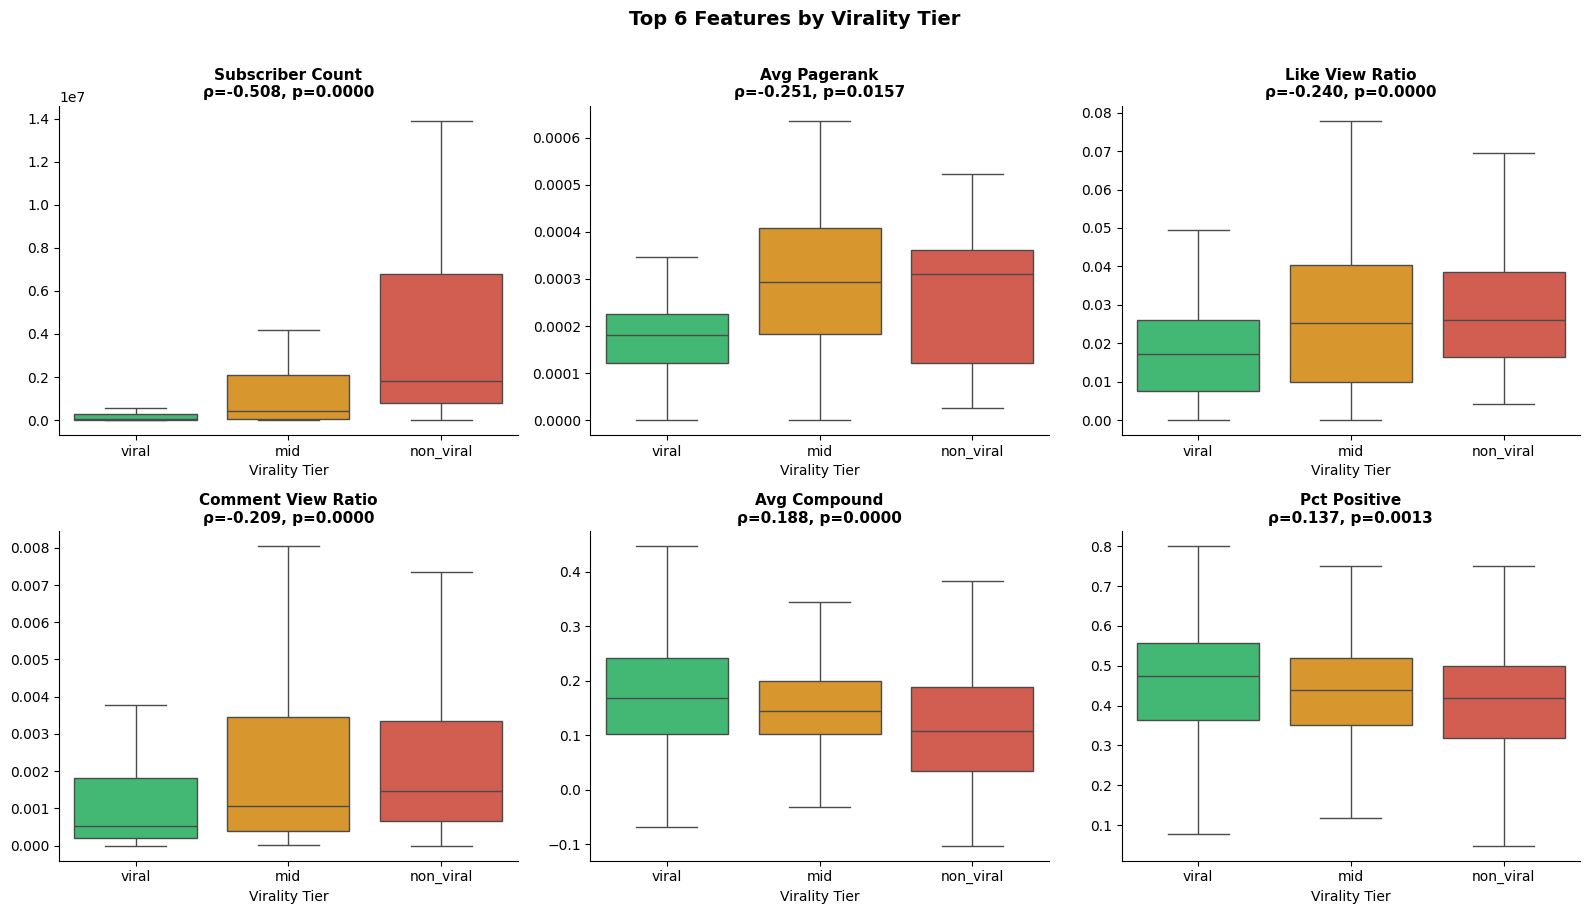

Saved: data/fig_feature_distributions.png


In [7]:
top6 = corr_df.head(6)['feature'].tolist()
plot_data = features_df[features_df['virality_tier'].isin(TIER_ORDER)]

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
for ax, feat in zip(axes.flatten(), top6):
    sns.boxplot(data=plot_data, x='virality_tier', y=feat,
                order=TIER_ORDER, palette=TIER_COLORS, ax=ax, showfliers=False)
    rho = corr_df[corr_df['feature'] == feat]['spearman_rho'].values[0]
    p   = corr_df[corr_df['feature'] == feat]['p_value'].values[0]
    ax.set_title(f"{feat.replace('_',' ').title()}\nρ={rho:.3f}, p={p:.4f}",
                 fontsize=11, fontweight='bold')
    ax.set_xlabel('Virality Tier', fontsize=10)
    ax.set_ylabel('')

plt.suptitle('Top 6 Features by Virality Tier', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('data/fig_feature_distributions.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: data/fig_feature_distributions.png")

## Cell 6 — Visualisation 3: Upload Timing Analysis

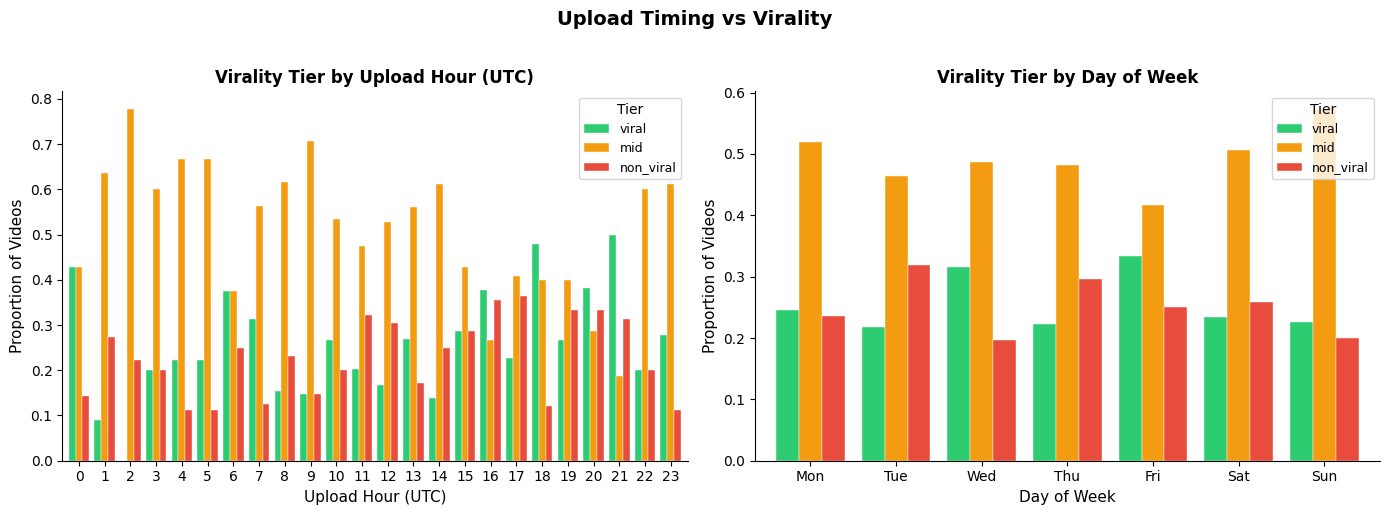

Saved: data/fig_upload_timing.png


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
DOW_LABELS = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']

for ax, col, label in [
    (axes[0], 'upload_hour', 'Upload Hour (UTC)'),
    (axes[1], 'upload_dow',  'Day of Week')
]:
    pivot = (
        plot_data.groupby([col, 'virality_tier']).size()
        .reset_index(name='count')
        .pivot(index=col, columns='virality_tier', values='count')
        .fillna(0)
    )
    pivot_norm = pivot.div(pivot.sum(axis=1), axis=0)
    pivot_norm.reindex(columns=TIER_ORDER).plot(
        kind='bar', ax=ax,
        color=[TIER_COLORS[t] for t in TIER_ORDER],
        edgecolor='white', linewidth=0.3, width=0.8
    )
    ax.set_xlabel(label, fontsize=11)
    ax.set_ylabel('Proportion of Videos', fontsize=11)
    ax.set_title(f'Virality Tier by {label}', fontsize=12, fontweight='bold')
    ax.legend(TIER_ORDER, title='Tier', fontsize=9)
    if col == 'upload_dow':
        ax.set_xticklabels(DOW_LABELS[:len(pivot_norm)], rotation=0)
    else:
        ax.tick_params(axis='x', rotation=0)

plt.suptitle('Upload Timing vs Virality', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('data/fig_upload_timing.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: data/fig_upload_timing.png")

## Cell 7 — Prepare ML Dataset

In [9]:
ml_data = features_df[features_df['virality_tier'].isin(TIER_ORDER)].copy()
X = ml_data[NUMERIC_FEATURES]
y = ml_data['virality_tier']

le = LabelEncoder()
y_enc = le.fit_transform(y)
print(f"Classes:            {le.classes_}")
print(f"Class distribution:\n{y.value_counts()}")

X_train, X_test, y_train, y_test = train_test_split(
    X, y_enc, test_size=0.2, random_state=42, stratify=y_enc
)
print(f"\nTrain: {len(X_train):,} | Test: {len(X_test):,}")

Classes:            ['mid' 'non_viral' 'viral']
Class distribution:
virality_tier
mid          276
non_viral    141
viral        141
Name: count, dtype: int64

Train: 446 | Test: 112


## Cell 8 — Cross-Validated Model Comparison

In [10]:
models = {
    'Logistic Regression': Pipeline([
        ('imp', SimpleImputer(strategy='median')),
        ('scl', StandardScaler()),
        ('clf', LogisticRegression(max_iter=1000, C=1.0, random_state=42))
    ]),
    'Random Forest': Pipeline([
        ('imp', SimpleImputer(strategy='median')),
        ('clf', RandomForestClassifier(n_estimators=200, max_depth=10,
                                       class_weight='balanced', random_state=42, n_jobs=-1))
    ]),
    'Gradient Boosting': Pipeline([
        ('imp', SimpleImputer(strategy='median')),
        ('clf', GradientBoostingClassifier(n_estimators=200, max_depth=4,
                                           learning_rate=0.05, random_state=42))
    ])
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_results = {}

print("5-fold stratified cross-validation:\n")
for name, pipe in models.items():
    res = cross_validate(pipe, X, y_enc, cv=cv,
                         scoring=['accuracy', 'f1_macro'], return_train_score=True)
    cv_results[name] = res
    print(f"{name}:")
    print(f"  Accuracy:  {res['test_accuracy'].mean():.4f} ± {res['test_accuracy'].std():.4f}")
    print(f"  F1 Macro:  {res['test_f1_macro'].mean():.4f} ± {res['test_f1_macro'].std():.4f}")

5-fold stratified cross-validation:

Logistic Regression:
  Accuracy:  0.5539 ± 0.0496
  F1 Macro:  0.5177 ± 0.0504
Random Forest:
  Accuracy:  0.7312 ± 0.0228
  F1 Macro:  0.7234 ± 0.0291
Gradient Boosting:
  Accuracy:  0.7007 ± 0.0332
  F1 Macro:  0.6944 ± 0.0358


## Cell 9 — Best Model: Test Set Evaluation

In [11]:
best_pipe = models['Random Forest']
best_pipe.fit(X_train, y_train)
y_pred = best_pipe.predict(X_test)

majority_class  = Counter(y_train).most_common(1)[0][0]
baseline_acc    = (y_test == majority_class).mean()
test_acc        = (y_pred == y_test).mean()

print("Random Forest — Test Set:")
print("=" * 50)
print(classification_report(y_test, y_pred, target_names=le.classes_, digits=4))
print(f"Majority baseline accuracy: {baseline_acc:.4f}")
print(f"Random Forest accuracy:     {test_acc:.4f}")
print(f"Improvement over baseline:  +{test_acc - baseline_acc:.4f}")

Random Forest — Test Set:
              precision    recall  f1-score   support

         mid     0.6885    0.7500    0.7179        56
   non_viral     0.7586    0.7857    0.7719        28
       viral     0.6818    0.5357    0.6000        28

    accuracy                         0.7054       112
   macro avg     0.7097    0.6905    0.6966       112
weighted avg     0.7044    0.7054    0.7020       112

Majority baseline accuracy: 0.5000
Random Forest accuracy:     0.7054
Improvement over baseline:  +0.2054


## Cell 10 — Visualisation 4: Confusion Matrix & Model Comparison

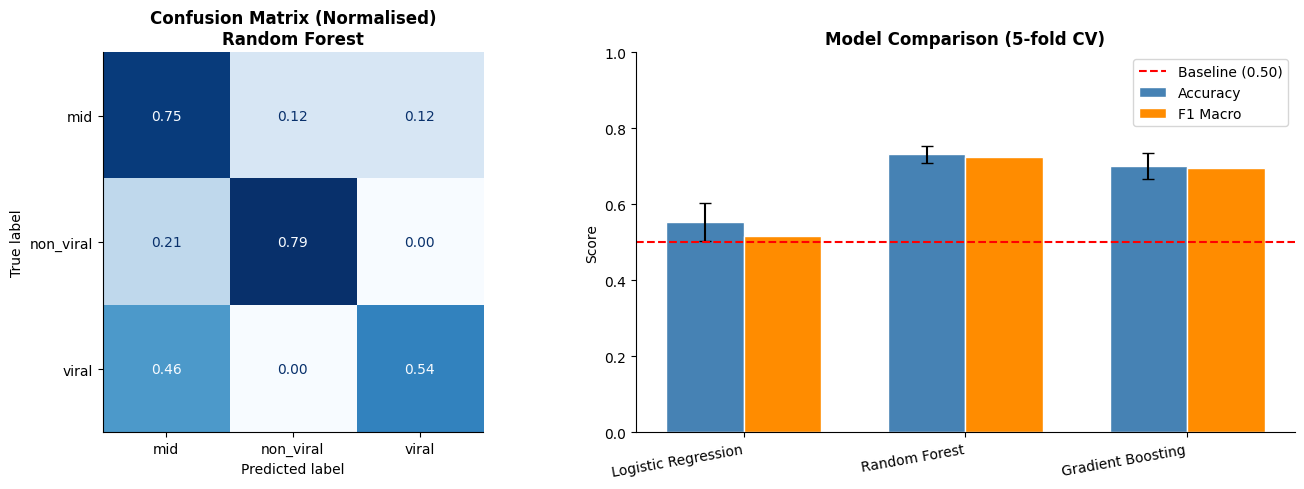

Saved: data/fig_model_comparison.png


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Normalised confusion matrix
ax = axes[0]
cm_norm = confusion_matrix(y_test, y_pred, normalize='true')
ConfusionMatrixDisplay(cm_norm, display_labels=le.classes_).plot(
    ax=ax, cmap='Blues', colorbar=False, values_format='.2f'
)
ax.set_title('Confusion Matrix (Normalised)\nRandom Forest', fontsize=12, fontweight='bold')

# Model comparison
ax2 = axes[1]
names = list(cv_results.keys())
acc_m = [cv_results[m]['test_accuracy'].mean() for m in names]
acc_s = [cv_results[m]['test_accuracy'].std()  for m in names]
f1_m  = [cv_results[m]['test_f1_macro'].mean() for m in names]
x = np.arange(len(names))
w = 0.35
ax2.bar(x - w/2, acc_m, w, yerr=acc_s, label='Accuracy', color='steelblue', capsize=4, edgecolor='white')
ax2.bar(x + w/2, f1_m,  w,             label='F1 Macro',  color='darkorange',               edgecolor='white')
ax2.axhline(baseline_acc, color='red', linestyle='--', linewidth=1.5,
            label=f'Baseline ({baseline_acc:.2f})')
ax2.set_xticks(x)
ax2.set_xticklabels(names, rotation=10, ha='right')
ax2.set_ylabel('Score')
ax2.set_title('Model Comparison (5-fold CV)', fontsize=12, fontweight='bold')
ax2.legend(fontsize=10)
ax2.set_ylim(0, 1)

plt.tight_layout()
plt.savefig('data/fig_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: data/fig_model_comparison.png")

## Cell 11 — Visualisation 5: Feature Importance

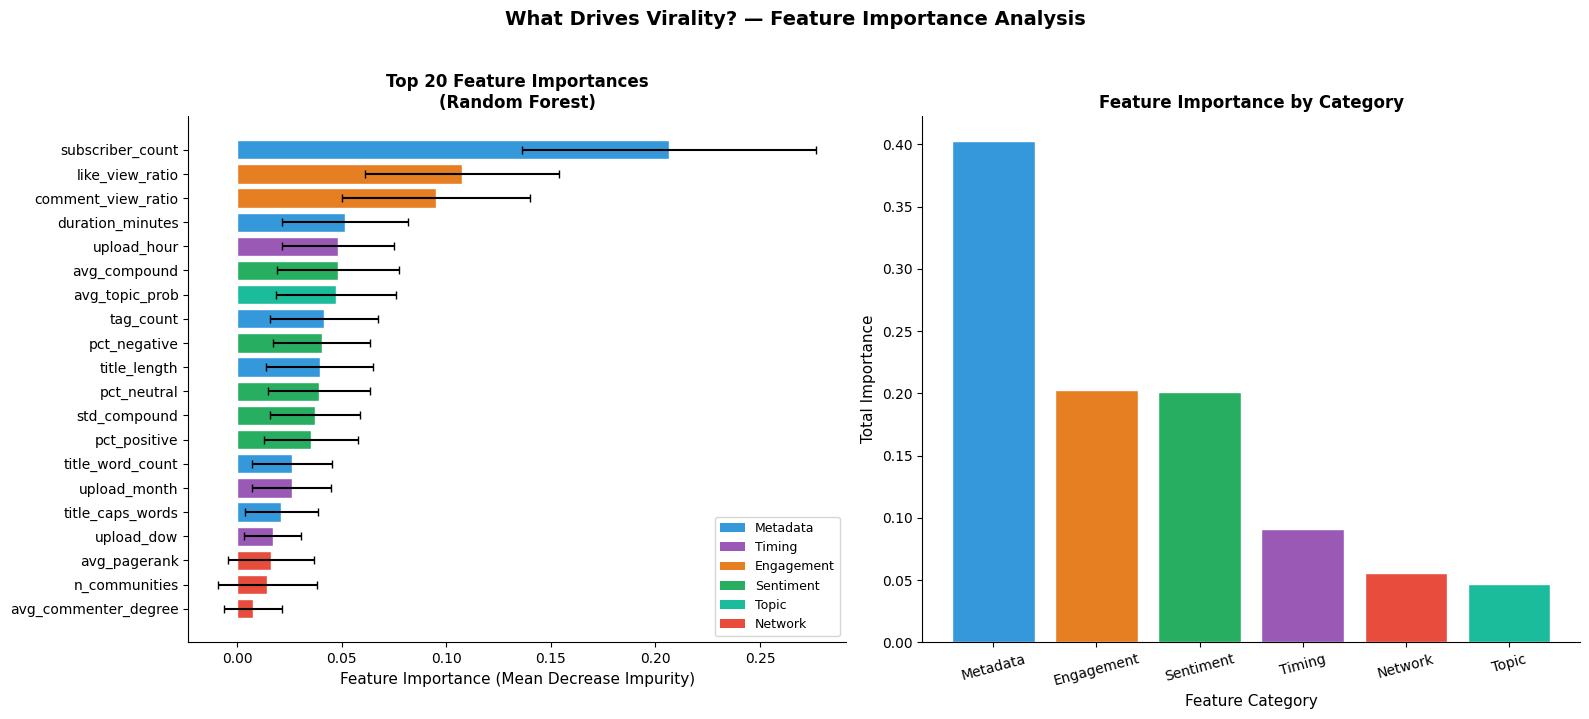

Saved: data/fig_feature_importance.png


In [13]:
rf_model    = best_pipe.named_steps['clf']
importances = rf_model.feature_importances_
imp_std     = np.std([t.feature_importances_ for t in rf_model.estimators_], axis=0)

imp_df = pd.DataFrame({
    'feature': NUMERIC_FEATURES,
    'importance': importances,
    'std': imp_std
}).sort_values('importance', ascending=False)

CAT_MAP = {
    'duration_minutes':'Metadata','subscriber_count':'Metadata',
    'title_length':'Metadata','title_word_count':'Metadata','tag_count':'Metadata',
    'title_has_excl':'Metadata','title_has_question':'Metadata',
    'title_has_number':'Metadata','title_caps_words':'Metadata',
    'upload_hour':'Timing','upload_dow':'Timing','upload_month':'Timing',
    'like_view_ratio':'Engagement','comment_view_ratio':'Engagement',
    'avg_compound':'Sentiment','std_compound':'Sentiment',
    'pct_positive':'Sentiment','pct_negative':'Sentiment','pct_neutral':'Sentiment',
    'avg_topic_prob':'Topic',
    'avg_commenter_degree':'Network','max_commenter_degree':'Network',
    'avg_pagerank':'Network','max_pagerank':'Network',
    'n_communities':'Network','avg_betweenness':'Network',
}
CAT_COLORS = {
    'Metadata':'#3498db','Timing':'#9b59b6','Engagement':'#e67e22',
    'Sentiment':'#27ae60','Topic':'#1abc9c','Network':'#e74c3c'
}
imp_df['category'] = imp_df['feature'].map(lambda x: CAT_MAP.get(x, 'Other'))
imp_df['color']    = imp_df['category'].map(CAT_COLORS)
top20 = imp_df.head(20)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

ax = axes[0]
ax.barh(top20['feature'][::-1], top20['importance'][::-1],
        xerr=top20['std'][::-1], color=top20['color'][::-1],
        edgecolor='white', capsize=3)
ax.set_xlabel('Feature Importance (Mean Decrease Impurity)', fontsize=11)
ax.set_title('Top 20 Feature Importances\n(Random Forest)', fontsize=12, fontweight='bold')
legend_els = [Patch(facecolor=c, label=cat) for cat, c in CAT_COLORS.items()]
ax.legend(handles=legend_els, fontsize=9, loc='lower right')

ax2 = axes[1]
cat_imp = imp_df.groupby('category')['importance'].sum().sort_values(ascending=False)
ax2.bar(cat_imp.index, cat_imp.values,
        color=[CAT_COLORS.get(c, 'grey') for c in cat_imp.index], edgecolor='white')
ax2.set_xlabel('Feature Category', fontsize=11)
ax2.set_ylabel('Total Importance', fontsize=11)
ax2.set_title('Feature Importance by Category', fontsize=12, fontweight='bold')
ax2.tick_params(axis='x', rotation=15)

plt.suptitle('What Drives Virality? — Feature Importance Analysis',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('data/fig_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: data/fig_feature_importance.png")

## Cell 12 — Virality Profile & Final Summary

In [14]:
profile_feats = [
    'duration_minutes', 'subscriber_count', 'tag_count', 'title_length',
    'avg_compound', 'pct_positive', 'pct_negative',
    'like_view_ratio', 'comment_view_ratio',
    'avg_commenter_degree', 'n_communities',
]
profile_feats = [f for f in profile_feats if f in features_df.columns]

profile = (
    features_df[features_df['virality_tier'].isin(TIER_ORDER)]
    .groupby('virality_tier')[profile_feats]
    .median().reindex(TIER_ORDER).round(4).T
)
profile.to_csv('data/virality_profile.csv')

print("VIRALITY PROFILE — Median values per tier:")
print(profile.to_string())

sig_n = len(corr_df[corr_df['significant']])
top3  = corr_df.head(3)

print(f"""
{'='*65}
PHASE 6 COMPLETE — SUMMARY
{'='*65}

Correlation Analysis:
  Features tested:           {len(corr_df)}
  Statistically significant: {sig_n} (p < 0.05)
  Top 3 correlates:
    1. {top3.iloc[0]['feature']:35s} rho={top3.iloc[0]['spearman_rho']:.4f}
    2. {top3.iloc[1]['feature']:35s} rho={top3.iloc[1]['spearman_rho']:.4f}
    3. {top3.iloc[2]['feature']:35s} rho={top3.iloc[2]['spearman_rho']:.4f}

ML Classification:
  Best model:       Random Forest
  CV Accuracy:      {cv_results['Random Forest']['test_accuracy'].mean():.4f} +/- {cv_results['Random Forest']['test_accuracy'].std():.4f}
  CV F1 Macro:      {cv_results['Random Forest']['test_f1_macro'].mean():.4f} +/- {cv_results['Random Forest']['test_f1_macro'].std():.4f}
  Majority baseline:{baseline_acc:.4f}

Files saved:
  data/feature_matrix.csv
  data/correlation_results.csv
  data/virality_profile.csv
  data/fig_correlation_analysis.png
  data/fig_feature_distributions.png
  data/fig_upload_timing.png
  data/fig_model_comparison.png
  data/fig_feature_importance.png
""")

VIRALITY PROFILE — Median values per tier:
virality_tier              viral          mid     non_viral
duration_minutes         10.2833      12.3583  1.058330e+01
subscriber_count      48800.0000  418500.0000  1.800000e+06
tag_count                14.0000      14.0000  1.700000e+01
title_length             51.0000      46.0000  4.600000e+01
avg_compound              0.1690       0.1446  1.080000e-01
pct_positive              0.4754       0.4384  4.186000e-01
pct_negative              0.1538       0.1533  1.964000e-01
like_view_ratio           0.0173       0.0252  2.620000e-02
comment_view_ratio        0.0005       0.0011  1.500000e-03
avg_commenter_degree      0.0691       0.0624  7.760000e-02
n_communities             0.0000       0.0000  0.000000e+00

PHASE 6 COMPLETE — SUMMARY

Correlation Analysis:
  Features tested:           26
  Statistically significant: 9 (p < 0.05)
  Top 3 correlates:
    1. subscriber_count                    rho=-0.5085
    2. avg_pagerank                  